In [71]:
import torch
import torchvision
from torchvision import datasets, transforms
from torchvision.datasets import ImageFolder
from torchvision.models import VGG16_Weights
from torch import Tensor
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import numpy as np
from collections import Counter
import copy
import shutil, zipfile, os
from google.colab import drive
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
!pip install torchinfo
from torchinfo import summary

Ispezionamento datasets

In [60]:
#ispezionamento
def inspect_dataset(dataset: ImageFolder):


  """Stampa un riepilogo diagnostico di un dataset ImageFolder.

    Mostra dimensione del dataset, forma e tipo di un campione, le classi
    con la loro mappatura a indici, e la distribuzione delle immagini tra
    le classi (per verificare il bilanciamento).

    Args:
        dataset (ImageFolder): il dataset da ispezionare. Deve essere
            un'istanza di torchvision.datasets.ImageFolder.

    Raises:
        TypeError: se dataset non è un'istanza di ImageFolder.
    """

  if not isinstance(dataset, ImageFolder):
        raise TypeError(f"Errore: Il parametro deve essere categoricamente di tipo ImageFolder. Ricevuto: {type(dataset).__name__}")

  print(f"Lunghezza dataset: {len(dataset)} elementi")
  print(f"Shape dataset: {dataset[0][0].shape}")
  print(f"Type dataset posizione [0]: {type(dataset[0])}")
  print(f"Lunghezza tupla: {len(dataset[0])}")
  print(f"Type Immagine: {type(dataset[0][0])}, dimensione {dataset[0][0].dtype}")
  print(f"Classi del dataset: {dataset.classes}")
  print(f"Indicizzazione classi: {dataset.class_to_idx}")
  print(f"Verifica bilanciamento classi: \n {Counter(dataset.targets)}")

Ispezionamento DataLoaders

In [61]:
#ispezione images, labels

def inspect_loaders(images:Tensor, labels:Tensor):

  """Stampa forma e tipo di un batch di immagini e delle relative etichette.

    Utile per verificare che un batch estratto da un DataLoader abbia le
    dimensioni e i dtype attesi (es. immagini float32 di forma
    (batch, canali, altezza, larghezza) ed etichette int64 di forma (batch,)).

    Args:
        images (Tensor): tensore del batch di immagini.
        labels (Tensor): tensore delle etichette corrispondenti.

    Raises:
        TypeError: se images o labels non sono istanze di torch.Tensor.
    """

  if not isinstance(images, Tensor):
        raise TypeError(f"Errore: Il parametro images deve essere categoricamente di tipo Tensor. Ricevuto: {type(images).__name__}")
  if not isinstance(labels, Tensor):
        raise TypeError(f"Errore: Il parametro labels deve essere categoricamente di tipo Tensor. Ricevuto: {type(labels).__name__}")

  print(f"Shape Immagine: {images.shape}")
  print(f"Tipo Immagine: {images.dtype}")
  print(f"Shape Label: {labels.shape}")
  print(f"Tipo Label: {labels.dtype}")

CREAZIONE MODELLI

- Baseline: modello base. Stessa architettura per base dati baseline e base dati augmented
- Transfer Learn: modello che parte da VGG16 e alla testa attacca una rete densa con output finale con 14 neuroni (uno per classe)

In [62]:
class Baseline(nn.Module):


    """Rete neurale convoluzionale per la classificazione di immagini di cibo.

      Architettura composta da quattro stadi convoluzionali (Conv2d + ReLU +
      MaxPool) con canali crescenti (3->32->64->128->256), ognuno dei quali
      dimezza le dimensioni spaziali. Un global average pooling collassa la
      feature map finale in un vettore di 256 valori, seguito da un classificatore
      denso (256->512->14) che produce i logit grezzi per le classi.
      L'ultimo layer non applica softmax: è previsto l'uso con nn.CrossEntropyLoss.

      Un'immagine di input di forma (batch, 3, 224, 224) produce in uscita un
      tensore (batch, num_classes) di logit.

      Args:
          num_classes (int): numero di classi in uscita. Default: 14.
      """





    def __init__(self, num_classes=14):
        super().__init__()
        #layer 1
        self.conv1 = nn.Conv2d(in_channels = 3,         #input shape: (32, 3, 224, 224), output shape: (32,32,224,224)
                               out_channels = 32,       #parametri: (3*3*3 + 1)*32 = 896
                               kernel_size = (3,3),
                               stride = 1,
                               padding = 1,
                               )
        self.relu1 = nn.ReLU()                          #nessun parametro
        self.pool1 = nn.MaxPool2d(kernel_size=2)        #nessun parametro, output shape: (32,32,112,112)


        #layer 2
        self.conv2 = nn.Conv2d(in_channels = 32,         #input shape: (32, 32, 112, 122), output shape: (32,64,112,112)
                               out_channels = 64,        #parametri: (32*3*3 + 1)*64 = 18496
                               kernel_size = (3,3),
                               stride = 1,
                               padding = 1,
                               )
        self.relu2 = nn.ReLU()                          #nessun parametro
        self.pool2 = nn.MaxPool2d(kernel_size=2)        #nessun parametro, output shape: (32,64,56,56)




        #layer 3
        self.conv3 = nn.Conv2d(in_channels = 64,         #input shape: (32, 64, 56, 56), output shape: (32,128,56,56)
                               out_channels = 128,       #parametri: (64*3*3 + 1)*128 = 73856
                               kernel_size = (3,3),
                               stride = 1,
                               padding = 1,
                               )
        self.relu3 = nn.ReLU()                          #nessun parametro
        self.pool3 = nn.MaxPool2d(kernel_size=2)        #nessun parametro, output shape: (32,128,28,28)

        #layer 4
        self.conv4 = nn.Conv2d(in_channels = 128,         #input shape: (32, 128, 28, 28), output shape: (32,256,28,28)
                               out_channels = 256,        #parametri: (128*3*3 + 1)*256 = 295168
                               kernel_size = (3,3),
                               stride = 1,
                               padding = 1,
                               )
        self.relu4 = nn.ReLU()                          #nessun parametro
        self.pool4 = nn.MaxPool2d(kernel_size=2)        #nessun parametro, output shape: (32,256,14,14)


        #layer di pooling
        self.glob = nn.AdaptiveAvgPool2d((1,1))         #input shape: (32,256,14,14), output shape: (32,256,1,1)

        #layer di classificazione
        self.dens1 = nn.Linear(in_features= 256, out_features= 512)   #parametri: (256 + 1)*512 = 131584
        self.relu5 = nn.ReLU()
        self.dens2 = nn.Linear(in_features= 512, out_features= num_classes)   #parametri: (512 + 1)*14 = 7182



    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.relu3(x)
        x = self.pool3(x)

        x = self.conv4(x)
        x = self.relu4(x)
        x = self.pool4(x)

        x = self.glob(x)
        x = torch.flatten(x, start_dim = 1)                #output shape: (32,256)

        x = self.dens1(x)
        x = self.relu5(x)
        x = self.dens2(x)

        return x

Disegno funzione di training

In [63]:
#definisco la funzione di calcolo della loss
def loss_error_function(model, dl_train, dl_val, criterion, optimizer, num_epochs = 1000, device = 'cuda', patience = 5):


  """Allena un modello con early stopping sulla loss di validazione.

    Per ogni epoca esegue una fase di training (con aggiornamento dei pesi) e
    una fase di validazione (in sola inferenza), registrando la loss media di
    entrambe. Applica l'early stopping: se la loss di validazione non migliora
    per un numero di epoche pari a `patience`, l'addestramento si interrompe.
    Al termine, i pesi del modello vengono ripristinati a quelli dell'epoca con
    la loss di validazione minima (il modello viene modificato sul posto).

    Args:
        model (nn.Module): il modello da addestrare.
        dl_train (DataLoader): DataLoader dei dati di training.
        dl_val (DataLoader): DataLoader dei dati di validazione.
        criterion: funzione di loss (es. nn.CrossEntropyLoss).
        optimizer: ottimizzatore agganciato ai parametri di `model`.
        num_epochs (int): numero massimo di epoche (tetto di sicurezza, di
            norma non raggiunto per via dell'early stopping). Default: 1000.
        device (str): dispositivo su cui eseguire l'addestramento ('cuda' o
            'cpu'). Default: 'cuda'.
        patience (int): numero di epoche consecutive senza miglioramento della
            loss di validazione tollerate prima di fermarsi. Default: 5.

    Returns:
        dict: dizionario con due chiavi, 'train' e 'val', ciascuna mappata alla
            lista delle loss medie per epoca (una voce per epoca eseguita).
    """



  # definisco le due liste di loss per train e val
  train_losses = []
  val_losses = []


  model = model.to(device)      #sposto il modello su gpu
  best_val_loss = float('inf')  #record da battere
  best_weights = copy.deepcopy(model.state_dict())     #pesi migliori finora
  epochs_no_improve = 0        #contatore pazienza


  for epoch in range(num_epochs):



    #############FASE DI TRAINING#############

    model.train()  #modalità training
    running_train_loss = 0.0

    for batch_idx, (images,labels) in enumerate(dl_train):

      #sposto images, labels su device
      images = images.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()           #azzero i gradienti
      labels_pred_train = model(images)              #calcolo l'output
      loss = criterion(labels_pred_train, labels)    #calcolo la losss
      loss.backward()                 #eseguo la backward
      optimizer.step()                #step dell'optimizer

      running_train_loss += loss.item()

      #if batch_idx % 10 == 0:                       # ogni 10 batch
      #      print(f"  batch {batch_idx}/{len(dl_train)}")

    epoch_train_loss = running_train_loss/len(dl_train)
    train_losses.append(epoch_train_loss)


  #############FASE DI VALUTAZIONE#############

    model.eval()   # modalità valutazione
    with torch.no_grad():

        running_val_loss = 0.0

        for images, labels in dl_val:

          images = images.to(device)
          labels = labels.to(device)

          labels_pred_val = model(images)
          loss = criterion(labels_pred_val, labels)
          running_val_loss += loss.item()



        epoch_val_loss = running_val_loss/len(dl_val)
        val_losses.append(epoch_val_loss)


        #################EARLY STOPPING#####################



        if epoch_val_loss < best_val_loss:
          best_val_loss = epoch_val_loss
          best_weights = copy.deepcopy(model.state_dict())
          epochs_no_improve = 0
        else:
          epochs_no_improve += 1
          if epochs_no_improve == patience:
            break

    print(f"Epoca {epoch+1}: train_loss = {epoch_train_loss}, val_loss = {epoch_val_loss} \n")

  model.load_state_dict(best_weights)


  return {'train': train_losses, 'val': val_losses}

Hyperparameters Tuning

In [64]:
def learning_rates_losses(dl_train, dl_val, num_epochs):


  """Confronta diversi learning rate addestrando un modello Baseline per ciascuno.

    Per ogni learning rate di una lista predefinita, istanzia un modello Baseline
    con gli stessi pesi iniziali (seed fissato per un confronto equo), lo allena
    tramite loss_error_function e ne registra la loss di validazione minima
    raggiunta. Permette di individuare il learning rate migliore come quello con
    la loss di validazione più bassa.

    Args:
        dl_train (DataLoader): DataLoader dei dati di training.
        dl_val (DataLoader): DataLoader dei dati di validazione.
        num_epochs (int): numero massimo di epoche per ciascun addestramento.

    Returns:
        dict: dizionario che mappa ogni learning rate (float) alla corrispondente
            loss di validazione minima (float).
    """

  lr_list = [0.0001,0.001,0.01,0.1] #lista di learning rates da valutare
  lr_scores ={}                    #definisco il dizionario delle loss per ciascun learning rate

  criterion =nn.CrossEntropyLoss() #funzione di Loss, comune ai vari modelli

  for lr in lr_list:

    print(f"Learning rate = {lr}\n")

    torch.manual_seed(17)         #riproducibilità tra i modelli per i diversi lr
    model = Baseline()
    optimizer = optim.Adam(model.parameters(), lr = lr)

    dict_lr = loss_error_function(model, dl_train, dl_val, criterion, optimizer, num_epochs= num_epochs)

    lr_scores[lr] = min(dict_lr['val'])

    print("\n\n")

  return lr_scores

Evaluation function

In [65]:
def evaluate(model, dl_test, dataset_test, device='cuda'):



    """Valuta un modello su un set di test e calcola le metriche di classificazione.

    Esegue il modello in modalità inferenza su tutti i batch del test set,
    ricava le classi predette e le confronta con le etichette
    reali. Restituisce accuracy, report dettagliato per classe e matrice di
    confusione.

    Args:
        model (nn.Module): il modello addestrato da valutare.
        dl_test (DataLoader): DataLoader dei dati di test.
        dataset_test (ImageFolder): dataset di test, usato per ricavare i nomi
            delle classi (dataset_test.classes) come etichette del report.
        device (str): dispositivo su cui eseguire la valutazione ('cuda' o
            'cpu'). Default: 'cuda'.

    Returns:
        tuple:
            accuracy (float): frazione di predizioni corrette sul test set.
            class_report (dict): report con precision, recall, f1-score e support
                per ogni classe, oltre alle medie macro e weighted
                (classification_report con output_dict=True).
            conf_matrix (np.ndarray): matrice di confusione di forma
                (num_classi, num_classi), con le classi vere sulle righe e le
                predette sulle colonne.
    """

    model = model.to(device) # sposto su device
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in dl_test:

            images = images.to(device) # sposto su device
            labels = labels.to(device)

            labels_pred_test = model(images) #forward
            predicted_labels = torch.argmax(labels_pred_test, dim = 1)   #classi predette

            #passo le previsioni e il test di nuovo a cpu per l'evaluation
            all_preds.append(predicted_labels.cpu())
            all_labels.append(labels.cpu())

    # concateno gli accumulatori in due array completi
    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()


    #calcolo accuracy
    accuracy = accuracy_score(all_labels, all_preds)
    #classification report
    class_report = classification_report(all_labels, all_preds, output_dict=True, target_names= dataset_test.classes)
    #confusion matrix
    conf_matrix = confusion_matrix(all_labels, all_preds)

    return accuracy, class_report, conf_matrix

Salvataggio modello in drive

In [66]:
def save_model_weights(model, path ,model_file:str):

  """Salva i pesi di un modello su Drive, creando la cartella se non esiste.

    Serializza lo state_dict del modello (i soli pesi, non l'architettura) nel
    percorso indicato. Per ricaricarli servirà istanziare un modello della stessa
    architettura e usare load_state_dict.

    Args:
        model (nn.Module): il modello di cui salvare i pesi.
        path (str): cartella di destinazione. Viene creata se non esiste.
        model_file (str): nome del file dei pesi (es. 'baseline.pt'), accodato
            a path per formare il percorso completo.
    """
  os.makedirs(path, exist_ok=True)   # crea la cartella se manca
  torch.save(model.state_dict(), path + model_file)

Caricamento modello da drive

In [67]:
def load_model_weights(model, path, device = 'cuda'):


  """Carica i pesi salvati in un modello e lo sposta sul dispositivo indicato.

    Legge lo state_dict dal percorso specificato e lo inserisce nel modello
    fornito, che deve avere la stessa architettura con cui i pesi sono stati
    salvati. Grazie a map_location, i pesi salvati da GPU possono essere caricati
    anche su CPU e viceversa.

    Args:
        model (nn.Module): istanza del modello (già costruito con l'architettura
            corretta) in cui caricare i pesi.
        path (str): percorso completo del file dei pesi.
        device (str): dispositivo su cui mappare i pesi e spostare il modello
            ('cuda' o 'cpu'). Default: 'cuda'.

    Returns:
        nn.Module: il modello con i pesi caricati, spostato su device.
    """

  model.load_state_dict(torch.load(path,map_location=device))
  model.to(device)
  return model

Salvataggio dizionari

In [68]:
def save_dict_json(dictionary, path, name_file):


  """Salva un dizionario in formato JSON su Drive, creando la cartella se manca.

    Serializza il dizionario in un file JSON leggibile (indentato). Adatto a
    dizionari contenenti solo tipi base (numeri, stringhe, liste, dizionari
    annidati), come le storie di loss o gli score dei learning rate.

    Args:
        dictionary (dict): il dizionario da salvare.
        path (str): cartella di destinazione. Viene creata se non esiste.
        name_file (str): nome del file JSON (es. 'baseline.json'), accodato a
            path per formare il percorso completo.
    """

  os.makedirs(path, exist_ok = True)

  with open(path + name_file, "w", encoding="utf-8") as f:
    json.dump(dictionary,f, indent = 4)

Caricamento dizionari

In [69]:
def load_dict_json(path, name_file):


    """Carica un dizionario da un file JSON su Drive.

    Legge e deserializza il contenuto di un file JSON, restituendolo come
    dizionario Python. Nota: le chiavi numeriche salvate in JSON vengono
    ricaricate come stringhe e vanno eventualmente riconvertite.

    Args:
        path (str): cartella che contiene il file.
        name_file (str): nome del file JSON da leggere, accodato a path per
            formare il percorso completo.

    Returns:
        dict: il dizionario deserializzato dal file JSON.
    """

    with open(path + name_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    return data

Plot curve di apprendimento

In [37]:
def plot_models_results(dictionaries:dict, models_list, entry_dict:str):

  fig, axes = plt.subplots(1, 3, figsize=(18, 5))


  for i, model_type in enumerate(models_list):

    axes[i].plot(dictionaries[model_type][entry_dict]['train'], label='train')
    axes[i].plot(dictionaries[model_type][entry_dict]['val'], label='val')
    axes[i].set_title(model_type)
    axes[i].set_xlabel('epoca')
    axes[i].set_ylabel('loss')
    axes[i].legend()

  plt.tight_layout()
  plt.show()

Heatmap function

In [15]:
def heatmap(conf_matrix, class_names, title=''):
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d',
                xticklabels=class_names, yticklabels=class_names, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predetto')
    plt.ylabel('Reale')
    plt.tight_layout()
    plt.show()

Funzione carica o allena modello

In [70]:
def get_or_train_model(path:str, file_pesi:str, file_dict:str, model, dl_train, dl_val, criterion, optimizer, num_epochs, choice):



  """Carica un modello già salvato oppure lo allena da zero, secondo la scelta.

    Se choice vale '1' e sono presenti sia il file dei pesi sia quello della
    storia di loss, carica il modello e il suo storico da Drive. Se choice è '1'
    ma manca almeno uno dei due file, ripiega sull'addestramento e salva i
    risultati. Per qualsiasi altro valore di choice, allena comunque il modello
    da zero e ne salva pesi e storia.

    Args:
        path (str): cartella in cui cercare/salvare i file del modello.
        file_pesi (str): nome del file dei pesi (es. 'baseline.pt').
        file_dict (str): nome del file JSON della storia di loss (es. 'baseline.json').
        model (nn.Module): istanza del modello, con l'architettura corretta.
        dl_train (DataLoader): DataLoader di training (usato in caso di addestramento).
        dl_val (DataLoader): DataLoader di validazione (usato in caso di addestramento).
        criterion: funzione di loss.
        optimizer: ottimizzatore agganciato ai parametri di `model`.
        num_epochs (int): numero massimo di epoche in caso di addestramento.
        choice (str): '1' per tentare il caricamento da disco, qualsiasi altro
            valore per forzare l'addestramento.

    Returns:
        tuple:
            model (nn.Module): il modello caricato o appena addestrato.
            dictionary (dict): la storia di loss con chiavi 'train' e 'val'.
    """

  if choice == '1':

    if os.path.exists(path+file_pesi) and os.path.exists(path+file_dict):
      # carica
      model = load_model_weights(model, path+file_pesi)
      dictionary = load_dict_json(path, file_dict)

    else:
      # allena e salva di default
      print(f"Presenza file pesi: {os.path.exists(path+file_pesi)}\nPresenza file loss: {os.path.exists(path+file_dict)}.\nInizio training come opzione di default")
      dictionary = loss_error_function(model, dl_train, dl_val, criterion, optimizer, num_epochs= num_epochs)
      save_model_weights(model, path, file_pesi)
      save_dict_json(dictionary, path, file_dict)

  else:

    dictionary = loss_error_function(model, dl_train, dl_val, criterion, optimizer, num_epochs= num_epochs)
    save_model_weights(model, path, file_pesi)
    save_dict_json(dictionary, path, file_dict)


  return model, dictionary


# **MAIN**

UNZIP DEL FILE DATASET IN LOCALE e RUNTIME GPU

In [17]:
#UNZIP
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Progetti Master/dataset_progetto_pytorch/dataset_food_classification.zip'


#estraggo i file da drive in locale, più veloce per il training
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall('/content/dataset_local')



#RUNTIME GPU
#assegno alla variabile device il runtimesu cui mi trovo per gestire i salvataggi su GPU
torch.manual_seed(17)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

Mounted at /content/drive
cuda


Transformazioni:

- train: preprocessing (resize, to_tensor, normalize) + augmented (rotazione e flip)
- test/val: preprocessing (resize, to_tensor, normalize)

In [18]:
#TRANSFORMATION

# valori di normalizzazione di ImageNet (obbligati per VGG16 pre-addestrato)
weights = VGG16_Weights.DEFAULT
auto_transform = weights.transforms()

imagenet_mean = auto_transform.mean
imagenet_std  = auto_transform.std

#definisco i transform
#train: faccio augmentation

transform_train = transforms.Compose([
                                  transforms.Resize((224,224)),
                                  transforms.RandomRotation(degrees = 45),
                                  transforms.RandomHorizontalFlip(p=0.5),
                                  transforms.ToTensor(),
                                  transforms.Normalize(imagenet_mean, imagenet_std)

])


#test/val: senza augmentation
transform_eval = transforms.Compose([


                                   transforms.Resize((224,224)),
                                   transforms.ToTensor(),
                                   transforms.Normalize(imagenet_mean, imagenet_std)


])

IMPORT DATASET E CREAZIONE DATALOADERS

In [22]:
#IMPORT DATASET

#importo il dataset con ImageFolder
content = '/content/dataset_local/dataset'
dataset_train_base = datasets.ImageFolder(root = content + '/train', transform= transform_eval) #dataset per il modello baseline, applico le stesse trasformazioni a meno di quelle augmented
dataset_train_aug = datasets.ImageFolder(root = content + '/train', transform= transform_train) #dataset per il modello augmented
dataset_test = datasets.ImageFolder(root = content + '/test', transform= transform_eval)
dataset_val = datasets.ImageFolder(root = content + '/val', transform= transform_eval)


#CREAZIONE DATALOADERS
dl_train_base = DataLoader(dataset_train_base, batch_size = 32, shuffle = True, pin_memory = True)
dl_train_aug = DataLoader(dataset_train_aug, batch_size = 32, shuffle = True, pin_memory = True)
dl_test = DataLoader(dataset_test, batch_size = 32, shuffle = False, pin_memory = True)
dl_val = DataLoader(dataset_val, batch_size = 32, shuffle = False, pin_memory = True)


#istanzio immagini e labels per ispezionare
images_train_base, labels_train_base = next(iter(dl_train_base))
images_train_aug, labels_train_aug = next(iter(dl_train_aug))
images_test, labels_test = next(iter(dl_test))
images_val, labels_val = next(iter(dl_val))

ISPEZIONAMENTO

In [23]:
#DATASET
#Ispezione dataset train baseline (stessa struttura di dataset_train_aug)
inspect_dataset(dataset_train_base)


print("\n")

#Ispezione dataset test
inspect_dataset(dataset_test)


print("\n")

#Ispezione dataset val
inspect_dataset(dataset_val)

print("\n\n")

#DATA LAODERS
#train
inspect_loaders(images_train_base, labels_train_base)

print("\n")


#test
inspect_loaders(images_test, labels_test)

print("\n")

#val
inspect_loaders(images_val, labels_val)

Lunghezza dataset: 8960 elementi
Shape dataset: torch.Size([3, 224, 224])
Type dataset posizione [0]: <class 'tuple'>
Lunghezza tupla: 2
Type Immagine: <class 'torch.Tensor'>, dimensione torch.float32
Classi del dataset: ['Baked Potato', 'Crispy Chicken', 'Donut', 'Fries', 'Hot Dog', 'Sandwich', 'Taco', 'Taquito', 'apple_pie', 'cheesecake', 'chicken_curry', 'ice_cream', 'omelette', 'sushi']
Indicizzazione classi: {'Baked Potato': 0, 'Crispy Chicken': 1, 'Donut': 2, 'Fries': 3, 'Hot Dog': 4, 'Sandwich': 5, 'Taco': 6, 'Taquito': 7, 'apple_pie': 8, 'cheesecake': 9, 'chicken_curry': 10, 'ice_cream': 11, 'omelette': 12, 'sushi': 13}
Verifica bilanciamento classi: 
 Counter({0: 640, 1: 640, 2: 640, 3: 640, 4: 640, 5: 640, 6: 640, 7: 640, 8: 640, 9: 640, 10: 640, 11: 640, 12: 640, 13: 640})


Lunghezza dataset: 2800 elementi
Shape dataset: torch.Size([3, 224, 224])
Type dataset posizione [0]: <class 'tuple'>
Lunghezza tupla: 2
Type Immagine: <class 'torch.Tensor'>, dimensione torch.float32
Cl

Le classi risultano tutte perfettamente bilanciate fra i vari dataset

HYPERPARAMETER TUNING

Trovo il miglior learning rate per il modello Baseline. Alleno su 10 epoche 4 differenti learning rate. Dopodiché scelgo il migliore

In [25]:
path = '/content/drive/MyDrive/Progetti Master/dataset_progetto_pytorch/'

choice = input("Digita 1 se desideri fare un hyperparameter tuning sul learning rate, digita altro se vuoi caricare da drive i valori di lr:\n")

if choice == "1":
  lr_losses = learning_rates_losses(dl_train_base, dl_val, num_epochs = 10)
  best_lr = float(min(lr_losses, key=lr_losses.get))
  print(f"Learning rates calcolati. Best lr = {best_lr}\n")

  with open(path+"lr_tuned.json", "w", encoding = 'utf-8') as f:
    json.dump(lr_losses, f, indent=4)
else:
  if os.path.exists(path+"lr_tuned.json"):

    lr_losses = load_dict_json(path,"lr_tuned.json")
    best_lr = float(min(lr_losses, key=lr_losses.get))
    print(f"Learning rates caricati da drive. Best lr = {best_lr}\n")

  else:
    print(f"Il file specificato non esiste nella cartella indicata: {path}\n")
    best_lr = 0.001 #valore di default
    print(f"Valore di default assegnato: Best lr = {best_lr}")

Digita 1 se desideri fare un hyperparameter tuning sul learning rate, digita altro se vuoi caricare da drive i valori di lr:
1
Epoca 1: train_loss = 2.51515040738242, val_loss = 2.4208838054112025 

Epoca 2: train_loss = 2.3689518417630877, val_loss = 2.35411297082901 

Epoca 3: train_loss = 2.268739670940808, val_loss = 2.2374444314411708 

Epoca 4: train_loss = 2.1744325906038284, val_loss = 2.189033113207136 

Epoca 5: train_loss = 2.112710480604853, val_loss = 2.1698897106306894 

Epoca 6: train_loss = 2.0651482352188655, val_loss = 2.3057803869247437 

Epoca 7: train_loss = 2.0311034440994264, val_loss = 2.05980338369097 

Epoca 8: train_loss = 2.0101922563144137, val_loss = 2.088587088244302 

Epoca 9: train_loss = 1.9548881181648798, val_loss = 1.9976646304130554 

Epoca 10: train_loss = 1.931157643880163, val_loss = 2.0182301453181677 

Epoca 1: train_loss = 2.4582647281033654, val_loss = 2.460599878856114 

Epoca 2: train_loss = 2.2484443455934526, val_loss = 2.184658418382917

ISTANZIAMENTO MODELLI

In [26]:
criterion =nn.CrossEntropyLoss() #funzione di Loss, comune ai vari modelli

############################BASE#################################
model_base = Baseline()
print("BASELINE\n")
print(summary(model_base, input_size=(32, 3, 224, 224)))
optimizer_base = optim.Adam(model_base.parameters(), lr = best_lr)

##########################AUGMENTED############################
model_aug = Baseline()
optimizer_aug = optim.Adam(model_aug.parameters(), lr = best_lr)

##########################TRANSFER#############################

#istanzio il modello VGG16
print("VGG16\n")
model_vgg = torchvision.models.vgg16(weights=weights)

#freeze dei parametri del feature extractore
for param in model_vgg.features.parameters():
    param.requires_grad = False

#freeze dei parametri del classificatore
for param in model_vgg.classifier.parameters():
    param.requires_grad = False


#cambio solo l'ultimo layer del classificatore passando da un 1000 a 14 classi, di default con requires_grad = True
model_vgg.classifier[6] = nn.Linear(in_features=4096, out_features=14)
print(model_vgg.classifier)


optimizer_tr = optim.Adam(
    filter(lambda p: p.requires_grad, model_vgg.parameters()),
    lr = best_lr)



num_parameters = sum(p.numel() for p in model_vgg.parameters() if p.requires_grad)
print(f"Numero parametri addestrabili modello transfer learning: {num_parameters}")

BASELINE

Layer (type:depth-idx)                   Output Shape              Param #
Baseline                                 [32, 14]                  --
├─Conv2d: 1-1                            [32, 32, 224, 224]        896
├─ReLU: 1-2                              [32, 32, 224, 224]        --
├─MaxPool2d: 1-3                         [32, 32, 112, 112]        --
├─Conv2d: 1-4                            [32, 64, 112, 112]        18,496
├─ReLU: 1-5                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-6                         [32, 64, 56, 56]          --
├─Conv2d: 1-7                            [32, 128, 56, 56]         73,856
├─ReLU: 1-8                              [32, 128, 56, 56]         --
├─MaxPool2d: 1-9                         [32, 128, 28, 28]         --
├─Conv2d: 1-10                           [32, 256, 28, 28]         295,168
├─ReLU: 1-11                             [32, 256, 28, 28]         --
├─MaxPool2d: 1-12                        [32, 256, 14, 14]   

100%|██████████| 528M/528M [00:03<00:00, 163MB/s]


Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=14, bias=True)
)
Numero parametri addestrabili modello transfer learning: 57358


CARICAMENTO MODELLI DA DRIVE O TRAINING

In [27]:
#Definisco un dizionario in cui salvo le caratteristiche principali di ogni modello
models_files_logic = {

                       'baseline':{

                                   "file_pesi": "baseline.pt",
                                   "file_dict": "baseline.json",
                                   "model": model_base,
                                   "optimizer": optimizer_base,
                                   "criterion": criterion,
                                   "dl_train": dl_train_base,
                                   "dl_val": dl_val

                       },



                       'augmented':{

                                   "file_pesi": "augmented.pt",
                                   "file_dict": "augmented.json",
                                   "model": model_aug,
                                   "optimizer": optimizer_aug,
                                   "criterion": criterion,
                                   "dl_train": dl_train_aug,
                                   "dl_val": dl_val

                       },



                       'transfer':{

                                   "file_pesi": "transferlr.pt",
                                   "file_dict": "transfer.json",
                                   "model": model_vgg,
                                   "optimizer": optimizer_tr,
                                   "criterion": criterion,
                                   "dl_train": dl_train_base, #alleno il vgg con i dati non transformati
                                   "dl_val": dl_val

                       }




}

#get_or_train_model(path:str, file_pesi:str, file_dict:str, model, dictionary:dict, dl_train, dl_val, criterion, optimizer, num_epochs)



#loop training o caricamento
loaded_trained_models = {} #in questo dizionario salvo i risultati dei miei training/caricamenti

for name, config in models_files_logic.items():

  choice = input(f"Digita 1 se intendi importare il modello {name} da drive, qualsiasi altro valore per eseguire il training: ")

  model, dictionary = get_or_train_model(path, config['file_pesi'],config['file_dict'],config['model'], config['dl_train'], config['dl_val'], config['criterion'],config['optimizer'], num_epochs = 50, choice= choice)
  loaded_trained_models[name] = {'model': model, 'dict': dictionary}

Digita 1 se intendi importare il modello baseline da drive, qualsiasi altro valore per eseguire il training: 2
Epoca 1: train_loss = 2.4180705394063677, val_loss = 2.321713708128248 

Epoca 2: train_loss = 2.2449091174772806, val_loss = 2.184835617882865 

Epoca 3: train_loss = 2.1079845079353876, val_loss = 2.1586904398032596 

Epoca 4: train_loss = 1.975028588942119, val_loss = 1.9914162414414542 

Epoca 5: train_loss = 1.8422384389809199, val_loss = 1.8041956978184837 

Epoca 6: train_loss = 1.723753190466336, val_loss = 1.7365743952138084 

Epoca 7: train_loss = 1.6360670383487428, val_loss = 1.6949366526944296 

Epoca 8: train_loss = 1.5228236372981752, val_loss = 1.5611078075000218 

Epoca 9: train_loss = 1.421057077390807, val_loss = 1.5006978350026268 

Epoca 10: train_loss = 1.3381245295916284, val_loss = 1.4284113568919046 

Epoca 11: train_loss = 1.2555072799324989, val_loss = 1.4396336776869638 

Epoca 12: train_loss = 1.1889623507857323, val_loss = 1.3376969235283989 

Epo

EVALUATION MODELLI

In [28]:
eval_results = {} #salvo i risultati delle mie evaluation

for name, config in loaded_trained_models.items():

  eval_results[name] = evaluate(config['model'], dl_test, dataset_test)

In [29]:
eval_results

{'baseline': (0.6189285714285714,
  {'Baked Potato': {'precision': 0.73224043715847,
    'recall': 0.67,
    'f1-score': 0.6997389033942559,
    'support': 200.0},
   'Crispy Chicken': {'precision': 0.7009803921568627,
    'recall': 0.715,
    'f1-score': 0.7079207920792079,
    'support': 200.0},
   'Donut': {'precision': 0.8181818181818182,
    'recall': 0.765,
    'f1-score': 0.7906976744186046,
    'support': 200.0},
   'Fries': {'precision': 0.7085714285714285,
    'recall': 0.62,
    'f1-score': 0.6613333333333333,
    'support': 200.0},
   'Hot Dog': {'precision': 0.5307017543859649,
    'recall': 0.605,
    'f1-score': 0.5654205607476636,
    'support': 200.0},
   'Sandwich': {'precision': 0.7681159420289855,
    'recall': 0.53,
    'f1-score': 0.6272189349112426,
    'support': 200.0},
   'Taco': {'precision': 0.42105263157894735,
    'recall': 0.56,
    'f1-score': 0.48068669527896996,
    'support': 200.0},
   'Taquito': {'precision': 0.4805194805194805,
    'recall': 0.555,

VISUALIZZAZIONE RISULTATI

In [56]:
righe = []
for nome, (acc, report, cm) in eval_results.items():
    righe.append({
        'modello': nome,
        'accuracy': round(acc, 4),
        'precision_macro': round(report['macro avg']['precision'], 4),
        'recall_macro': round(report['macro avg']['recall'], 4),
        'f1_macro': round(report['macro avg']['f1-score'], 4)
    })

tabella = pd.DataFrame(righe)
tabella

,modello,accuracy,precision_macro,recall_macro,f1_macro
0,baseline,0.6189,0.6319,0.6189,0.6217
1,augmented,0.5950,0.6129,0.5950,0.5957
2,transfer,0.7693,0.7738,0.7693,0.7701


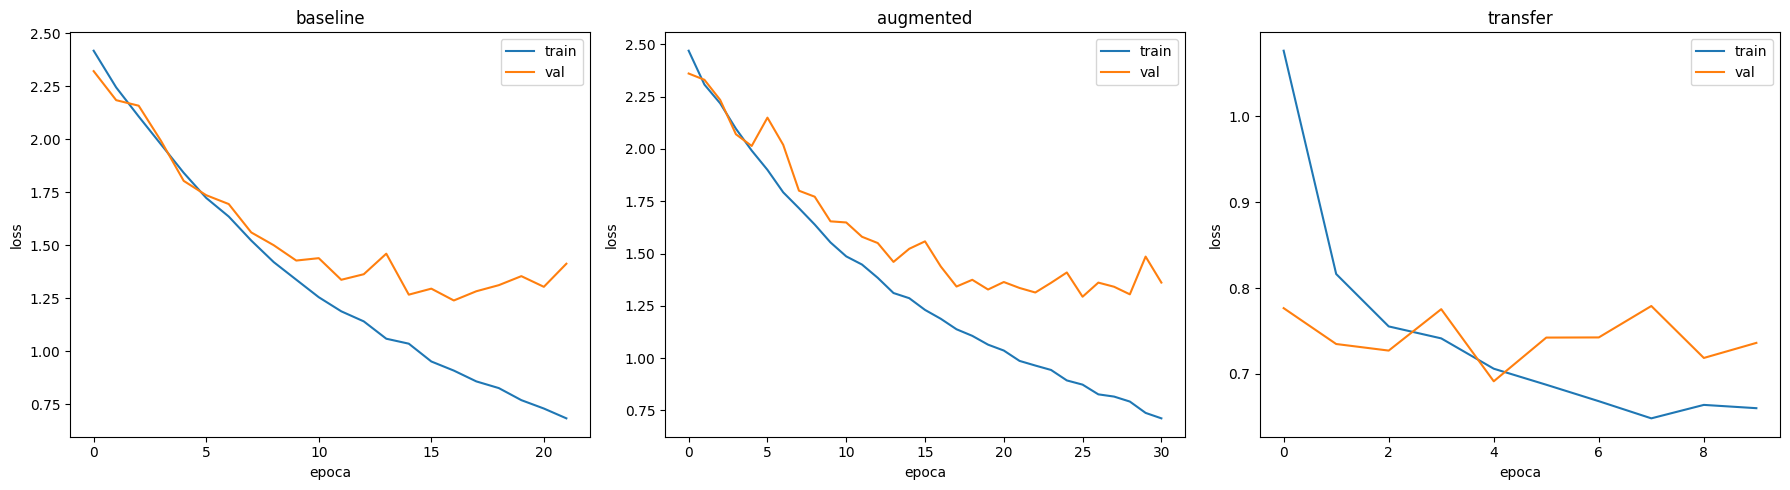

In [57]:
##PLOT DELLE LOSS

models_list = ['baseline','augmented','transfer']
entry_dict = 'dict' #dove si trova il dizionario delle epoche in loaded_trained_models

plot_models_results(loaded_trained_models, models_list = models_list, entry_dict = entry_dict)

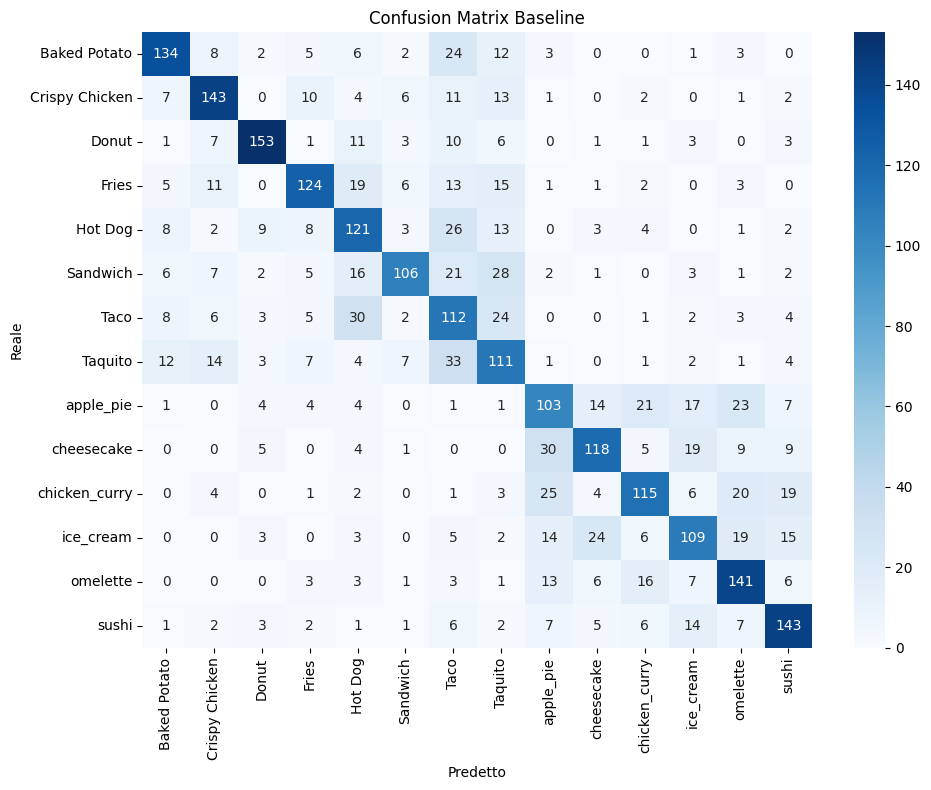

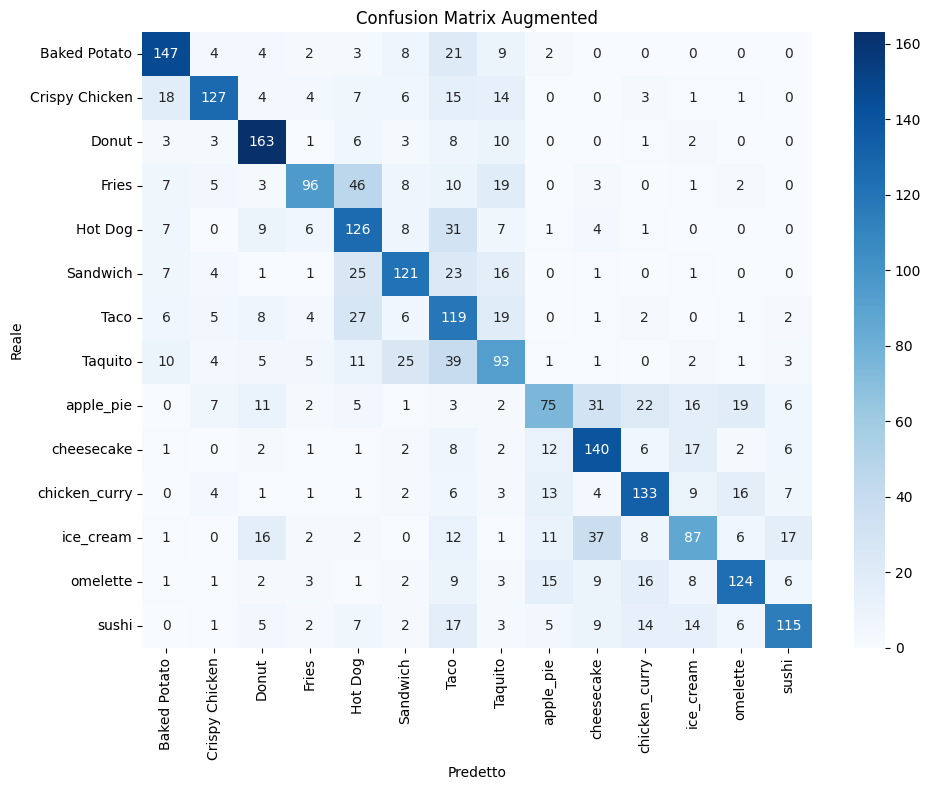

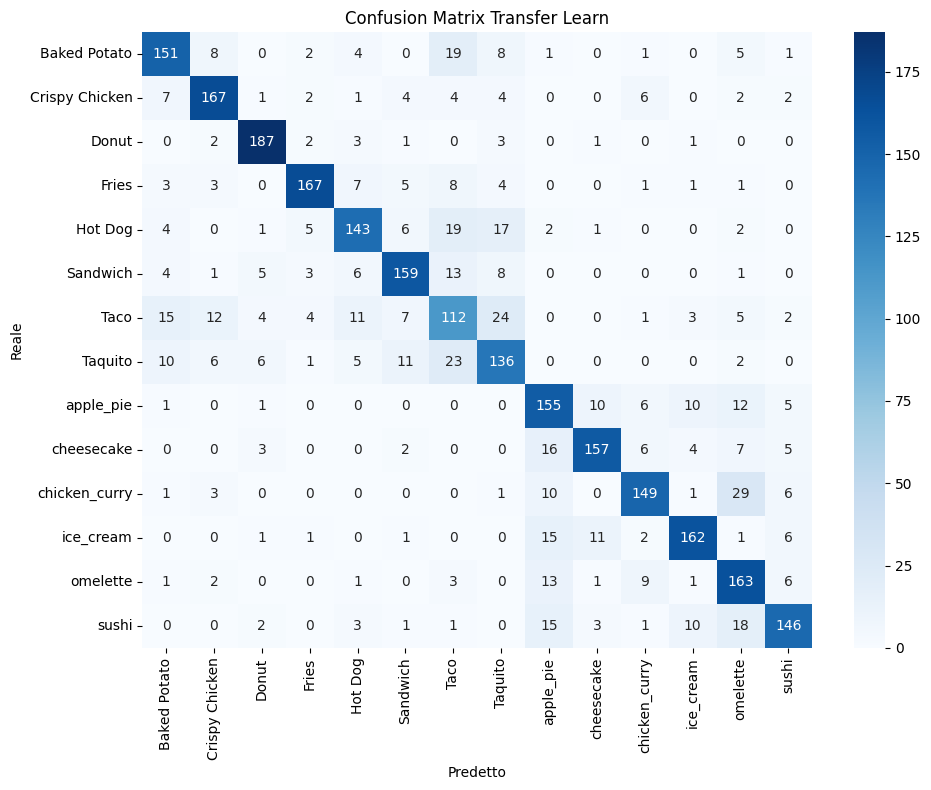

In [53]:
#HEATMAP
class_names = list(eval_results['baseline'][1].keys()) #isolo il nome delle classi
class_names = class_names[:-3]  #taglio gli ultimi tre elementi che sono 'accuracy','macro avg', 'weighted avg'


#baseline
heatmap(eval_results['baseline'][2], class_names, title = 'Confusion Matrix Baseline')



#augmented
heatmap(eval_results['augmented'][2], class_names, title = 'Confusion Matrix Augmented')


#transfer
heatmap(eval_results['transfer'][2], class_names, title = 'Confusion Matrix Transfer Learn')

# **COMMENTO FINALE**

# Conclusioni

## Sintesi dei risultati

Sono stati sviluppati e confrontati tre modelli per la classificazione di 14 categorie
di cibo, valutati sul medesimo test set di 2800 immagini (200 per classe):

| Modello   | Accuracy | F1 (macro) | Parametri addestrati |
|-----------|----------|------------|----------------------|
| Baseline (CNN da zero)   | ~0.62 | ~0.62 | ~527.000 |
| Augmented (CNN + augmentation) | ~0.60 | ~0.60 | ~527.000 |
| Transfer (VGG16 pre-addestrato) | **~0.77** | **~0.77** | **~57.000** |

## Il transfer learning è la soluzione più efficace

Il modello basato su VGG16 pre-addestrato ha nettamente superato le reti addestrate
da zero, con un guadagno di circa 15-17 punti percentuali di accuracy. Il dato più
significativo è l'efficienza: questo risultato è stato ottenuto addestrando solo il
classificatore finale (~57.000 parametri, contro i ~527.000 delle CNN da zero) e in
sole ~10 epoche. Riutilizzando le rappresentazioni visive apprese da VGG16 su
ImageNet, il modello parte da una base di conoscenza che le reti da zero devono
faticosamente ricostruire. Per un contesto applicativo come quello di GourmetAI, questo
si traduce in prestazioni superiori a fronte di costi di addestramento sensibilmente
inferiori.

## L'effetto dell'augmentation è modesto su questa architettura

Baseline e modello con augmentation hanno mostrato prestazioni molto simili, con
differenze (~2 punti) rientranti nella normale variabilità tra addestramenti dovuta
all'inizializzazione casuale. Non è quindi possibile affermare un vantaggio robusto
dell'augmentation in termini di accuracy finale su questa CNN. Le curve di loss
mostrano tuttavia che l'augmentation agisce sulla dinamica di addestramento: il modello
augmented ha richiesto più epoche prima dell'early stopping. Il beneficio
dell'augmentation sarebbe presumibilmente più marcato su un'architettura di maggiore
capacità o con un addestramento più prolungato.

## Gli errori sono sistematici e interpretabili

Le matrici di confusione rivelano che, in tutti e tre i modelli, gli errori si
concentrano tra classi visivamente affini: i cibi salati/fritti si confondono tra loro
(in particolare Taco e Taquito, la coppia più difficile) e i dolci/morbidi tra loro
(apple_pie, cheesecake, ice_cream). Le confusioni tra i due gruppi sono rare. Ciò indica
che i modelli hanno appreso la macro-struttura visiva del dominio e che gli errori
residui riguardano distinzioni oggettivamente ambigue anche per un osservatore umano.

## Nota sui tempi di addestramento

I tempi di addestramento effettivo dei tre modelli (su GPU) sono stati dell'ordine di 2 ore in totale:
il modello transfer, pur avendo un costo per epoca maggiore (VGG16 è una rete profonda,
il cui forward attraversa ~138 milioni di parametri anche se congelati), è converso
in poche epoche grazie all'early stopping, risultando competitivo nei tempi complessivi
oltre che superiore nelle prestazioni. Le CNN addestrate da zero hanno un costo per epoca
inferiore ma richiedono più epoche per convergere.

## Sviluppi futuri

Per migliorare ulteriormente le prestazioni si potrebbe: applicare il fine-tuning degli
ultimi stadi convoluzionali di VGG16 (non solo del classificatore); combinare transfer
learning e augmentation; introdurre tecniche di regolarizzazione aggiuntive (dropout); e mediare i risultati su più run per un confronto statisticamente solido.